## Imports

In [24]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay ,accuracy_score
import matplotlib.pyplot as plt



In [2]:
tf.__version__

'2.20.0'

## Data preprocessing

Importing the dataset

In [3]:
data = pd.read_csv("data/Churn_Modelling.csv")

X = data.iloc[:, 3:-1].values
y = data.iloc[:, -1].values


In [4]:
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [5]:
print(y)

[1 0 1 ... 1 1 0]


## Encoding categorical data

Label encoding "Gender" column


In [6]:
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

In [7]:
print(X)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


OneHotEncoding to "Geography" column

In [8]:
ct = ColumnTransformer(transformers=[("encoder", OneHotEncoder(),[1])],remainder="passthrough")
X = np.array(ct.fit_transform(X))


In [9]:
print(X)

[[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


## Splitting the dataset to train and test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scalling

In [11]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
print(X_train)

[[ 1.00150113 -0.57946723 -0.57638802 ...  0.64920267  0.97481699
   1.36766974]
 [-0.99850112  1.72572313 -0.57638802 ...  0.64920267  0.97481699
   1.6612541 ]
 [-0.99850112 -0.57946723  1.73494238 ...  0.64920267 -1.02583358
  -0.25280688]
 ...
 [ 1.00150113 -0.57946723 -0.57638802 ... -1.54035103 -1.02583358
  -0.1427649 ]
 [ 1.00150113 -0.57946723 -0.57638802 ...  0.64920267 -1.02583358
  -0.05082558]
 [-0.99850112  1.72572313 -0.57638802 ...  0.64920267  0.97481699
  -0.81456811]]


In [13]:
print(X_test)

[[-0.99850112  1.72572313 -0.57638802 ... -1.54035103 -1.02583358
  -1.01960511]
 [ 1.00150113 -0.57946723 -0.57638802 ...  0.64920267  0.97481699
   0.79888291]
 [-0.99850112 -0.57946723  1.73494238 ...  0.64920267 -1.02583358
  -0.72797953]
 ...
 [ 1.00150113 -0.57946723 -0.57638802 ...  0.64920267 -1.02583358
  -1.16591585]
 [ 1.00150113 -0.57946723 -0.57638802 ...  0.64920267 -1.02583358
  -0.41163463]
 [-0.99850112  1.72572313 -0.57638802 ...  0.64920267  0.97481699
   0.12593183]]


## Building ANN

Initializing ANN

In [14]:
ann = tf.keras.models.Sequential()

Adding the input layer and the first hidden layer

In [15]:
ann.add(tf.keras.layers.Dense(units=6, activation="relu"))

Adding second hidden layer

In [16]:
ann.add(tf.keras.layers.Dense(units=6, activation="relu"))

Adding the output layer

In [17]:
ann.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

## Training the ANN

Compiling the ANN

In [18]:
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Training the ANN on training set

In [19]:
ann.fit(X_train, y_train, batch_size=32, epochs=100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7631 - loss: 0.5319
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7945 - loss: 0.4799
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7945 - loss: 0.4618
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7945 - loss: 0.4475
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7946 - loss: 0.4343
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8005 - loss: 0.4211
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8084 - loss: 0.4086
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8120 - loss: 0.3968
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8341 - loss: 0.3867
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8470 - loss: 0.3789
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8496 - loss: 0.3727
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━

## Predictions and evaluating the model

Predicting the result of a single observation

In [22]:
print(ann.predict(sc.transform([[1, 0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]]))> 0.5)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[False]]


Predicting the Test results

In [23]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)

print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[0 0]
 [0 0]
 [0 0]
 ...
 [1 1]
 [0 1]
 [0 1]]


Making the Confusion Matrix

Confusion Matrix: [[1535   72]
 [ 210  183]]
Accuracy score: 0.859


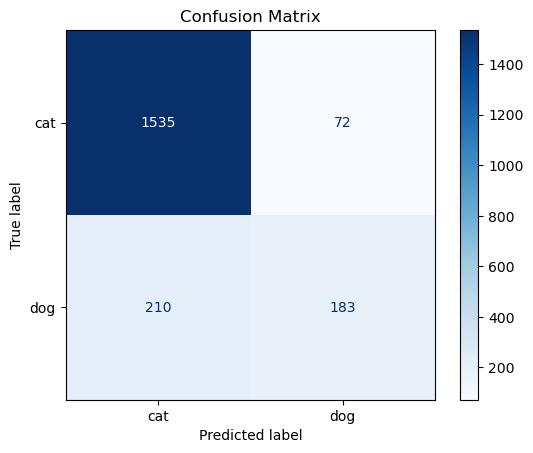

In [25]:
cm = confusion_matrix(y_test,y_pred)
print(f"Confusion Matrix: {cm}")

acc_s = accuracy_score(y_test,y_pred)
print(f"Accuracy score: {acc_s}")

fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Saving trained model

In [26]:
save_path = "models/artifical_neural_networks.keras"

ann.save(save_path)

print(f"Model saved successfully to: {save_path}")

Model saved successfully to: models/artifical_neural_networks.keras
